# NPE_A - GaussianNoiseSimulatorDistractor

In [1]:
import lfi
import numpy as np
import matplotlib.pyplot as plt
import torch

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## D: 2

### budget: 1_000

In [2]:
np.random.seed(42)
torch.manual_seed(1925)

In [3]:
# modeling parameters
prior_low = - 10
prior_high = 10
prior_dim = 2
simulator_sigma_noise = 0.1
observation_nof_obs = 1

# Distractor Parameters
distractor_dim=10
distractor_scale=100

# Total Observation dim
total_simulator_dim = prior_dim + distractor_dim

In [4]:
budget = 1000
num_components = 10
batch_size = 1_000
max_num_epochs = 1_000
nof_samples = 100

In [5]:
prior = lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.GaussianNoiseDistractor(dim=prior_dim, dim_y=total_simulator_dim, sigma_noise=simulator_sigma_noise, distractor_dim=distractor_dim, distractor_scale=distractor_scale)
obs = lfi.observations.Zeros(dim_y = total_simulator_dim, nof_observations=observation_nof_obs)
observation = obs.sample()


In [6]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [7]:
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
        "num_components": num_components
    }
)

  0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 468 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [8]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [10]:
ground_truth = lfi.ground_truth.Gaussian(dim=prior_dim, mu = 0, sigma=simulator_sigma_noise)
samples_gt = ground_truth.sample(nof_samples=nof_samples)

<Figure size 640x480 with 0 Axes>

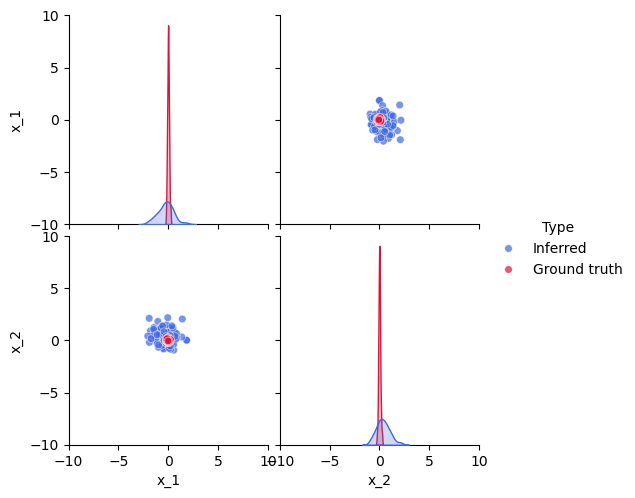

In [11]:
lfi.visualization.plot_pairwise_posterior(
    samples,
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)

In [12]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st is: {c2st}")

c2st is: 0.95


### budget: 5_000

In [13]:
np.random.seed(42)
torch.manual_seed(1925)

In [14]:
# modeling parameters
prior_low = - 10
prior_high = 10
prior_dim = 2
simulator_sigma_noise = 0.1
observation_nof_obs = 1

# Distractor Parameters
distractor_dim=10
distractor_scale=100

# Total Observation dim
total_simulator_dim = prior_dim + distractor_dim

In [15]:
budget = 5000
num_components = 10
batch_size = 1_000
max_num_epochs = 1_000
nof_samples = 100

In [16]:
prior = lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.GaussianNoiseDistractor(dim=prior_dim, dim_y=total_simulator_dim, sigma_noise=simulator_sigma_noise, distractor_dim=distractor_dim, distractor_scale=distractor_scale)
obs = lfi.observations.Zeros(dim_y = total_simulator_dim, nof_observations=observation_nof_obs)
observation = obs.sample()


In [17]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [18]:
prior = lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.GaussianNoiseDistractor(dim=prior_dim, dim_y=total_simulator_dim, sigma_noise=simulator_sigma_noise, distractor_dim=distractor_dim, distractor_scale=distractor_scale)
obs = lfi.observations.Zeros(dim_y = total_simulator_dim, nof_observations=observation_nof_obs)
observation = obs.sample()


In [19]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [20]:
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
        "num_components": num_components
    }
)

  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 214 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [21]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [22]:
ground_truth = lfi.ground_truth.Gaussian(dim=prior_dim, mu = 0, sigma=simulator_sigma_noise)
samples_gt = ground_truth.sample(nof_samples=nof_samples)

<Figure size 640x480 with 0 Axes>

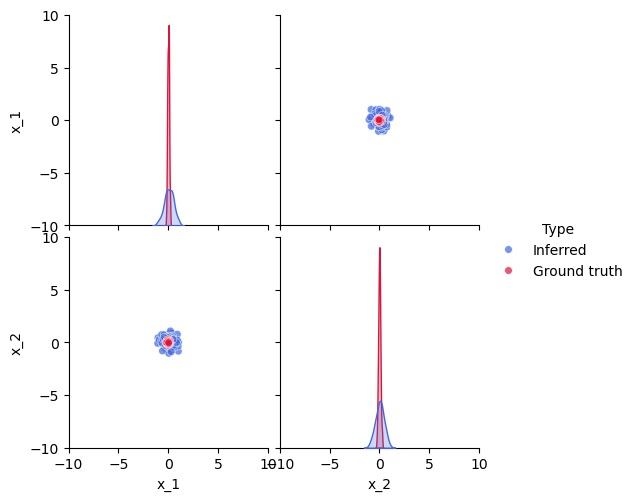

In [23]:
lfi.visualization.plot_pairwise_posterior(
    samples,
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)

In [24]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st is: {c2st}")

c2st is: 0.93


#### budget: 10_000

In [28]:
np.random.seed(42)
torch.manual_seed(1925)

In [29]:
# modeling parameters
prior_low = - 10
prior_high = 10
prior_dim = 2
simulator_sigma_noise = 0.1
observation_nof_obs = 1

# Distractor Parameters
distractor_dim=10
distractor_scale=100

# Total Observation dim
total_simulator_dim = prior_dim + distractor_dim

In [30]:
budget = 10_000
num_components = 10
batch_size = 1_000
max_num_epochs = 1_000
nof_samples = 100

In [31]:
prior = lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.GaussianNoiseDistractor(dim=prior_dim, dim_y=total_simulator_dim, sigma_noise=simulator_sigma_noise, distractor_dim=distractor_dim, distractor_scale=distractor_scale)
obs = lfi.observations.Zeros(dim_y = total_simulator_dim, nof_observations=observation_nof_obs)
observation = obs.sample()


In [32]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [33]:
prior = lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.GaussianNoiseDistractor(dim=prior_dim, dim_y=total_simulator_dim, sigma_noise=simulator_sigma_noise, distractor_dim=distractor_dim, distractor_scale=distractor_scale)
obs = lfi.observations.Zeros(dim_y = total_simulator_dim, nof_observations=observation_nof_obs)
observation = obs.sample()


In [34]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [35]:
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
        "num_components": num_components
    }
)

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 301 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [36]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [37]:
ground_truth = lfi.ground_truth.Gaussian(dim=prior_dim, mu = 0, sigma=simulator_sigma_noise)
samples_gt = ground_truth.sample(nof_samples=nof_samples)

<Figure size 640x480 with 0 Axes>

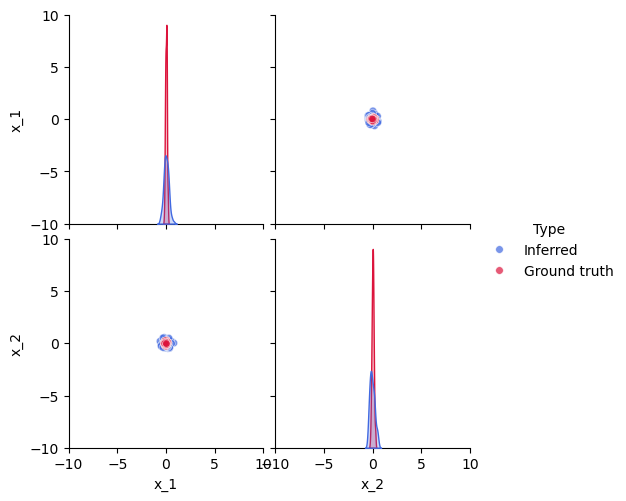

In [38]:
lfi.visualization.plot_pairwise_posterior(
    samples,
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)

In [39]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st is: {c2st}")

c2st is: 0.85


### budget: 50_000

In [40]:
np.random.seed(42)
torch.manual_seed(1925)

In [41]:
# modeling parameters
prior_low = - 10
prior_high = 10
prior_dim = 2
simulator_sigma_noise = 0.1
observation_nof_obs = 1

# Distractor Parameters
distractor_dim=10
distractor_scale=100

# Total Observation dim
total_simulator_dim = prior_dim + distractor_dim

In [42]:
budget = 50_000
num_components = 10
batch_size = 1_000
max_num_epochs = 1_000
nof_samples = 100

In [43]:
prior = lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.GaussianNoiseDistractor(dim=prior_dim, dim_y=total_simulator_dim, sigma_noise=simulator_sigma_noise, distractor_dim=distractor_dim, distractor_scale=distractor_scale)
obs = lfi.observations.Zeros(dim_y = total_simulator_dim, nof_observations=observation_nof_obs)
observation = obs.sample()


In [44]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [45]:
prior = lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.GaussianNoiseDistractor(dim=prior_dim, dim_y=total_simulator_dim, sigma_noise=simulator_sigma_noise, distractor_dim=distractor_dim, distractor_scale=distractor_scale)
obs = lfi.observations.Zeros(dim_y = total_simulator_dim, nof_observations=observation_nof_obs)
observation = obs.sample()


In [46]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [47]:
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
        "num_components": num_components
    }
)

  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 142 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [48]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [49]:
ground_truth = lfi.ground_truth.Gaussian(dim=prior_dim, mu = 0, sigma=simulator_sigma_noise)
samples_gt = ground_truth.sample(nof_samples=nof_samples)

<Figure size 640x480 with 0 Axes>

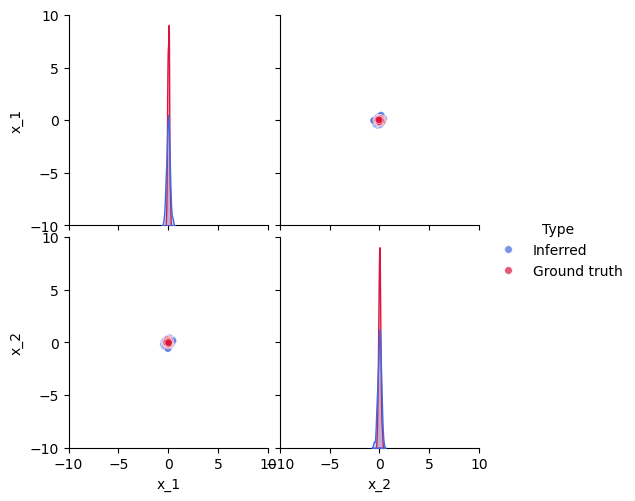

In [50]:
lfi.visualization.plot_pairwise_posterior(
    samples,
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)

In [51]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st is: {c2st}")

c2st is: 0.6799999999999999


### budget: 100_000

In [52]:
np.random.seed(42)
torch.manual_seed(1925)

In [53]:
# modeling parameters
prior_low = - 10
prior_high = 10
prior_dim = 2
simulator_sigma_noise = 0.1
observation_nof_obs = 1

# Distractor Parameters
distractor_dim=10
distractor_scale=100

# Total Observation dim
total_simulator_dim = prior_dim + distractor_dim

In [54]:
budget = 100_000
num_components = 10
batch_size = 1_000
max_num_epochs = 1_000
nof_samples = 100

In [55]:
prior = lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.GaussianNoiseDistractor(dim=prior_dim, dim_y=total_simulator_dim, sigma_noise=simulator_sigma_noise, distractor_dim=distractor_dim, distractor_scale=distractor_scale)
obs = lfi.observations.Zeros(dim_y = total_simulator_dim, nof_observations=observation_nof_obs)
observation = obs.sample()


In [56]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [57]:
prior = lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
simulator = lfi.simulators.GaussianNoiseDistractor(dim=prior_dim, dim_y=total_simulator_dim, sigma_noise=simulator_sigma_noise, distractor_dim=distractor_dim, distractor_scale=distractor_scale)
obs = lfi.observations.Zeros(dim_y = total_simulator_dim, nof_observations=observation_nof_obs)
observation = obs.sample()


In [58]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=observation
)

In [59]:
inference.fit(
    budget=budget,
    fit_kwargs = {
        "batch_size": batch_size,
        "num_components": num_components
    }
)

  0%|          | 0/100000 [00:00<?, ?it/s]

 Neural network successfully converged after 97 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [60]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [62]:
ground_truth = lfi.ground_truth.Gaussian(dim=prior_dim, mu = 0, sigma=simulator_sigma_noise)
samples_gt = ground_truth.sample(nof_samples=nof_samples)

<Figure size 640x480 with 0 Axes>

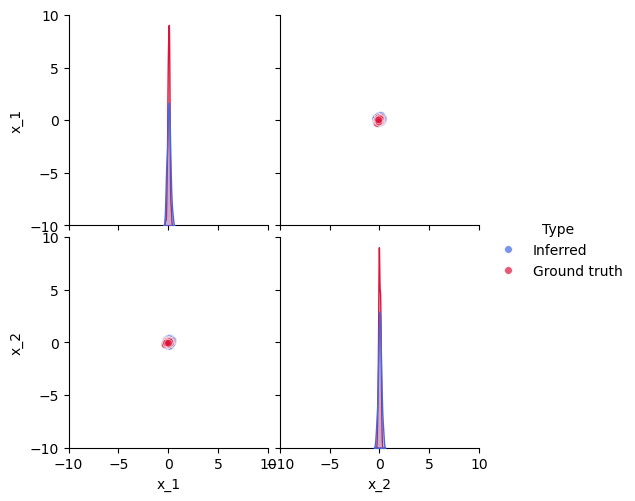

In [63]:
lfi.visualization.plot_pairwise_posterior(
    samples,
    limits = [prior_low, prior_high],
    samples_gt = samples_gt
)

In [64]:
c2st = lfi.evaluation.c2st(samples, samples_gt)
print(f"c2st is: {c2st}")

c2st is: 0.655
